# Emission Models

This notebook demonstrates how to construct emission models to be used in synthetic diagnostics.

In [1]:
import numpy as np
import ultraplot as uplt
from raysect.core.math import Point3D, Vector3D
from raysect.core.workflow import MulticoreEngine
from raysect.optical import Ray, Spectrum, World
from rich import print as rprint
from rich.table import Table

from cherab.core.atomic import Isotope, Line, elements
from cherab.core.math import sample3d
from cherab.core.model import Bremsstrahlung, ExcitationLine, RecombinationLine
from cherab.imas.datasets import iter_jintrac
from cherab.imas.plasma import load_plasma
from cherab.openadas import OpenADAS

# Set dark background for plots
uplt.rc.style = "dark_background"

/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/__init__.py:221: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


## Retrieve atomic data

[OpenADAS](https://open.adas.ac.uk) provides data for a variety of emission processes in plasmas.
Here we demonstrate how to include some of these processes in a `cherab` simulation and generate synthetic spectra.

In [2]:
atomic_data = OpenADAS(permit_extrapolation=True, missing_rates_return_null=False)

In [3]:
from cherab.openadas.install import install_files
from cherab.openadas.repository import populate

try:
    atomic_data.ionisation_rate(elements.neon, 1)
    atomic_data.recombination_pec(elements.neon, 1, ("2s1 2p6 2s0.5", "2s2 2p5 2p2.5"))
except RuntimeError:
    print("Populating OpenADAS repository...")

    # Download ADAS files from OpenADAS
    populate()

    # Install ADAS files that are not downloaded by default
    # TODO: uncomment tungsten ADF15 once https://github.com/cherab/core/pull/497 is resolved
    install_files(
        {
            # "adf11scd": ((elements.tungsten, "adf11/scd50/scd50_w.dat"),),
            # "adf11acd": ((elements.tungsten, "adf11/acd50/acd50_w.dat"),),
            "adf15": [
                (elements.neon, i, f"adf15/pec96#ne/pec96#ne_pjr#ne{i}.dat")
                for i in range(elements.neon.atomic_number)
            ],
            # + [
            #     (elements.tungsten, i, f"adf15/pec40#w/pec40#w_ic#w{i}.dat")
            #     for i in range(elements.tungsten.atomic_number)
            # ],
        },
        download=True,
    )

Populating OpenADAS repository...
Installing adf11/scd12/scd12_h.dat...
 - downloading ADF file 'adf11/scd12/scd12_h.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd12/scd12_h.dat'


Installing adf11/scd96/scd96_he.dat...
 - downloading ADF file 'adf11/scd96/scd96_he.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd96/scd96_he.dat'


Installing adf11/scd96/scd96_li.dat...
 - downloading ADF file 'adf11/scd96/scd96_li.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd96/scd96_li.dat'


Installing adf11/scd96/scd96_be.dat...
 - downloading ADF file 'adf11/scd96/scd96_be.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd96/scd96_be.dat'


Installing adf11/scd89/scd89_b.dat...
 - downloading ADF file 'adf11/scd89/scd89_b.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd89/scd89_b.dat'


...

Installing adf15/pec96#ne/pec96#ne_pjr#ne5.dat...
 - downloading ADF file 'adf15/pec96#ne/pec96#ne_pjr#ne5.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf15/pec96#ne/pec96#ne_pjr#ne5.dat'


Installing adf15/pec96#ne/pec96#ne_pjr#ne6.dat...
 - downloading ADF file 'adf15/pec96#ne/pec96#ne_pjr#ne6.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf15/pec96#ne/pec96#ne_pjr#ne6.dat'


Installing adf15/pec96#ne/pec96#ne_pjr#ne7.dat...
 - downloading ADF file 'adf15/pec96#ne/pec96#ne_pjr#ne7.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf15/pec96#ne/pec96#ne_pjr#ne7.dat'


Installing adf15/pec96#ne/pec96#ne_pjr#ne8.dat...
 - downloading ADF file 'adf15/pec96#ne/pec96#ne_pjr#ne8.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf15/pec96#ne/pec96#ne_pjr#ne8.dat'


Installing adf15/pec96#ne/pec96#ne_pjr#ne9.dat...
 - downloading ADF file 'adf15/pec96#ne/pec96#ne_pjr#ne9.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf15/pec96#ne/pec96#ne_pjr#ne9.dat'


## Load full plasma from IMAS

The details of loading a full plasma are covered in the [Full Plasma](./3_full_plasma.ipynb) notebook.
Here we simply load a plasma from an IMAS jintrac dataset.

In [4]:
world = World()
path = iter_jintrac()
plasma = load_plasma(path, parent=world, atomic_data=atomic_data)

07:49:02 INFO     Parsing data dictionary version 4.1.1 @dd_zip.py:89


07:49:02 INFO     Parsing data dictionary version 4.0.0 @dd_zip.py:89


/home/runner/work/imas/imas/src/cherab/imas/plasma/blend.py:181: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  core_profiles_ids = get_ids_time_slice(


/home/runner/work/imas/imas/src/cherab/imas/plasma/blend.py:207: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  edge_profiles_ids = get_ids_time_slice(
/home/runner/work/imas/imas/src/cherab/imas/plasma/equilibrium.py:104: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  equilibrium_ids = get_ids_time_slice(


/home/runner/work/imas/imas/src/cherab/imas/plasma/equilibrium.py:188: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  equilibrium_ids = get_ids_time_slice(


Warning! Unable to verify that the cell nodes are in the winding order.


Warning! Using average ion temperature for the D ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+1).
Warning! Using average ion temperature for the Ne ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+3).
Warning! Using average ion temperature for the Ne ion (z=+4).
Warning! Using average ion temperature for the Ne ion (z=+5).
Warning! Using average ion temperature for the Ne ion (z=+6).
Warning! Using average ion temperature for the Ne ion (z=+7).
Warning! Using average ion temperature for the Ne ion (z=+8).
Warning! Using average ion temperature for the Ne ion (z=+9).
Warning! Using average ion temperature for the Ne ion (z=+10).
Warning! Using average ion temperature for the W ion (z=+1).
Warning! Using average ion temperature for the W ion (z=+2).
Warning! Using average ion temperature for the W ion (z=+3).
Warning! Us

Warning! Species of type 'molecule' are currently not supported.
The following species will be skipped: D-D molecule


Show which species the plasma is composed of.

In [5]:
# Organize plasma species by symbol and charge
species = {}
for s in plasma.composition:
    symbol = s.element.symbol
    if symbol not in species:
        species[symbol] = []
    species[symbol].append(s)

# Sort species of each element by charge
for symbol in species:
    species[symbol].sort(key=lambda x: (x.element.atomic_number, x.element.atomic_weight, x.charge))

# Print table of plasma species
table = Table(title="Plasma Species")
table.add_column("Element", style="cyan", justify="right")
table.add_column("Charge", justify="left")
for symbol in species:
    charges = [s.charge for s in species[symbol]]
    charges_split = [charges[i : i + 10] for i in range(0, len(charges), 10)]
    charges_strs = [", ".join(f"{c:d}+" for c in split) for split in charges_split]
    charges_str = "\n".join(charges_strs)
    table.add_row(symbol, charges_str)
rprint(table)

                        Plasma Species                        
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Element ┃ Charge                                           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       D │ 0+, 1+                                           │
│       T │ 0+, 1+                                           │
│      He │ 0+, 1+, 2+                                       │
│      Ne │ 0+, 1+, 2+, 3+, 4+, 5+, 6+, 7+, 8+, 9+           │
│         │ 10+                                              │
│       W │ 0+, 1+, 2+, 3+, 4+, 5+, 6+, 7+, 8+, 9+           │
│         │ 10+, 11+, 12+, 13+, 14+, 15+, 16+, 17+, 18+, 19+ │
│         │ 20+, 21+, 22+, 23+, 24+, 25+, 26+, 27+, 28+, 29+ │
│         │ 30+, 31+, 32+, 33+, 34+, 35+, 36+, 37+, 38+, 39+ │
│         │ 40+, 41+, 42+, 43+, 44+, 45+, 46+, 47+, 48+, 49+ │
│         │ 50+, 51+, 52+, 53+, 54+, 55+, 56+, 57+, 58+, 59+ │
│         │ 60+, 61+, 62+, 63+, 64+, 65+, 66+, 67+, 68+, 69+ │
│         │ 70+, 71+, 72+, 73+, 74+                          │
└─────────┴──────────────────────────────────────────────────┘

## Construct emission models

### Apply emission models to plasma species

Here we create emission models for Bremsstrahlung, excitation lines, and recombination lines for the main plasma species (D, T, He, Ne, W).

We consider all excitation/recombination lines stored in the OpenADAS adf15 files for these species, which are saved in the `~/.cherab/openadas/repository/pec/...` directory after downloading the files from OpenADAS.


In [6]:
import json
from pathlib import Path

from cherab.openadas.repository.utility import DEFAULT_REPOSITORY_PATH

lines_exc = []
lines_rec = []

for elm in [
    elements.deuterium,
    elements.tritium,
    elements.helium,
    elements.neon,
    # elements.tungsten,  # TODO: uncomment once https://github.com/cherab/core/pull/497 is resolved
]:
    ion_elm = elm.element if isinstance(elm, Isotope) else elm

    # === Excitation Lines ===
    dir_exc = Path(DEFAULT_REPOSITORY_PATH) / f"pec/excitation/{ion_elm.symbol.lower()}"
    paths_pec_exc = list(dir_exc.glob("*.json"))
    if len(paths_pec_exc) == 0:
        raise ValueError(
            f"No excitation data found for element {ion_elm.symbol} in the repository {dir_exc}"
        )

    for path in paths_pec_exc:
        with path.open("r") as f:
            data_exc = json.load(f)

        charge = int(path.stem)
        for transition in data_exc.keys():
            lines_exc.append(
                ExcitationLine(
                    Line(elm, charge, tuple(transition.split(" -> "))),
                ),
            )

    # === Recombination Lines ===
    if ion_elm == elements.tungsten:
        # Skip recombination lines for tungsten since they are not available in the repository
        continue

    dir_rec = Path(DEFAULT_REPOSITORY_PATH) / f"pec/recombination/{ion_elm.symbol.lower()}"
    paths_pec_rec = list(dir_rec.glob("*.json"))
    if len(paths_pec_rec) == 0:
        raise ValueError(
            f"No recombination data found for element {ion_elm.symbol} in the repository {dir_rec}"
        )
    for path in paths_pec_rec:
        with path.open("r") as f:
            data_rec = json.load(f)

        charge = int(path.stem)
        for transition in data_rec.keys():
            lines_rec.append(
                RecombinationLine(
                    Line(elm, charge, tuple(transition.split(" -> "))),
                ),
            )

Apply the Bremsstrahlung and line emission models to the plasma object.

In [7]:
plasma.models = [
    Bremsstrahlung(),
    *lines_exc,
    *lines_rec,
]

### Visualize emission profiles

Let us visualize the total emission from all processes on a 2D grid in the R-Z plane.
Due to the heavy computational load, we limit the grid resolution to 50 mm and wavelength range to 0.01–1000 nm with 50 bins per each decade.


In [8]:
# Grid specification
R_MIN, R_MAX = 4.0, 8.5
Z_MIN, Z_MAX = -4.5, 4.4
RES = 50.0e-3  # resolution of grid in [m]
n_r = round((R_MAX - R_MIN) / RES) + 1
n_z = round((Z_MAX - Z_MIN) / RES) + 1
extent = (R_MIN, R_MAX, Z_MIN, Z_MAX)

# Define wavelength integration bands as (min_wavelength_nm, max_wavelength_nm).
# We split the full 0.01–1000 nm range into decade intervals.
#
# Why this structure:
# - Raysect/Cherab spectra use linearly spaced bins within each Spectrum object.
# - Using multiple adjacent decade bands approximates logarithmic coverage overall,
#   while preserving linear binning locally in each band.
wavelength_bands = [
    (0.01, 0.1),
    (0.1, 1.0),
    (1.0, 10.0),
    (10.0, 100.0),
    (100.0, 1000.0),
]
wavelength_bins = 50  # number of bins per decade band

Sample emission at each grid point integrating over the defined wavelength bands.

In [9]:
class Emission2DSample:
    def __init__(
        self,
        plasma,
        r_pts,
        z_pts,
        wavelength_bands,
        wavelength_bins,
    ) -> None:
        self.plasma = plasma
        self.r_pts = r_pts
        self.z_pts = z_pts
        self.indices = list(np.ndindex(len(r_pts), len(z_pts)))
        self.wavelength_bands = wavelength_bands
        self.wavelength_bins = wavelength_bins
        self.engine = MulticoreEngine()
        self.emission_2d = np.zeros((len(r_pts), len(z_pts)))

    def run(self) -> None:
        self.engine.run(
            self.indices,
            self._render,
            self._update,
        )

    def _render(self, idx) -> float:
        i_r, i_z = idx
        x = self.r_pts[i_r]
        z = self.z_pts[i_z]

        n_e = self.plasma.electron_distribution.density(x, 0, z)
        if n_e <= 0:
            return idx, 0.0

        total = 0.0
        for min_wl, max_wl in self.wavelength_bands:
            spectrum = Spectrum(
                min_wavelength=min_wl,
                max_wavelength=max_wl,
                bins=self.wavelength_bins,
            )
            total += self._emission(x, 0, z, spectrum)
        return idx, total

    def _update(self, packed_result) -> None:
        (i_r, i_z), value = packed_result
        self.emission_2d[i_r, i_z] = value

    def _emission(self, x, y, z, spectrum: Spectrum) -> float:
        """Calculate total emission at a point for a given spectrum."""
        for model in self.plasma.models:
            spectrum = model.emission(
                Point3D(x, y, z),
                Vector3D(0, 1, 0),
                spectrum,
            )
        return spectrum.total()


# Get R, Z sampling points
r_pts, _, z_pts, _ = sample3d(
    lambda x, y, z: 0,
    (R_MIN, R_MAX, n_r),
    (0, 0, 1),
    (Z_MIN, Z_MAX, n_z),
)

# Create emission sampler and run
emission_sampler = Emission2DSample(
    plasma,
    r_pts,
    z_pts,
    wavelength_bands,
    wavelength_bins,
)
emission_sampler.run()

Plot the 2-D emission map

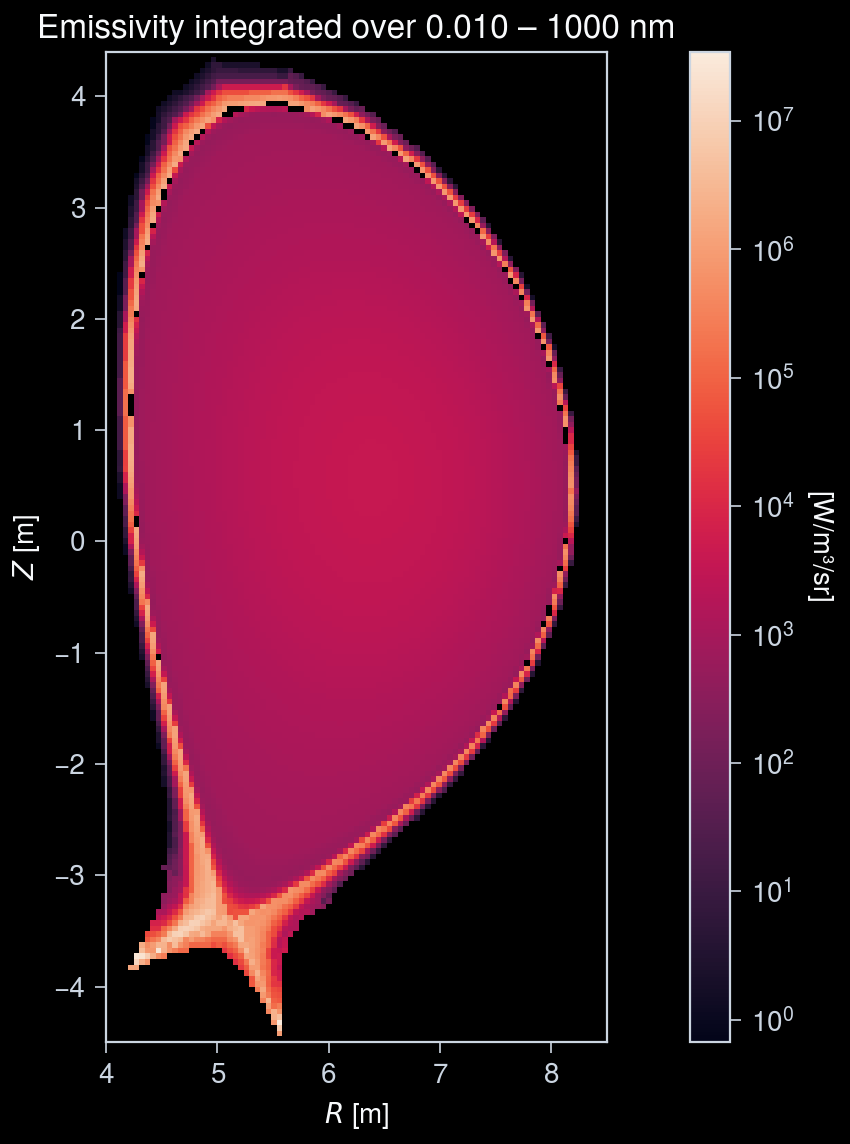

In [10]:
emission_2d = emission_sampler.emission_2d
emission_2d[emission_2d <= 0] = np.nan  # for log plotting

fig, ax = uplt.subplots()
ax.imshow(
    emission_2d.T,
    discrete=False,
    extent=extent,
    origin="lower",
    norm="log",
    cmap="rocket",
    colorbar="r",
    colorbar_kw=dict(
        tickdir="out",
        formatter="log",
        label="[W/m³/sr]",
    ),
)
ax.format(
    aspect="equal",
    title=f"Emissivity integrated over {wavelength_bands[0][0]:.3f} – {wavelength_bands[-1][1]:.0f} nm",
    xlabel="$R$ [m]",
    ylabel="$Z$ [m]",
    xlocator=1,
    ylocator=1,
)

In [11]:
dr = np.mean(np.diff(r_pts))
dz = np.mean(np.diff(z_pts))
total_power = 2.0 * np.pi * dr * dz * r_pts[:, None] * emission_2d * 4.0 * np.pi

print(f"Total radiated power: {np.nansum(total_power) * 1e-6:.3g} MW")

Total radiated power: 877 MW


## Measure line-of-sight Spectra

Here we measure line-of-sight spectra through the above modeled emission.

In [12]:
class MeasureLoS:
    def __init__(self, world) -> None:
        self.engine = MulticoreEngine()
        self.world = world
        self.results: list[Spectrum] = []

    def run(self, rays) -> list[Spectrum]:
        self.results.clear()
        self.engine.run(rays, self.render, self.update)
        result = sorted(
            self.results,
            key=lambda x: x.min_wavelength,
        )
        return result

    def render(self, ray: Ray) -> Spectrum:
        return ray.trace(self.world)

    def update(self, result: Spectrum) -> None:
        self.results.append(result)


measure = MeasureLoS(world)

In [13]:
# Generate rays with defined wavelength bands
origin = Point3D(7.5, 0, 4.0)
endpoint = Point3D(4.8, 0, -4.2)
direction = origin.vector_to(endpoint).normalise()
rays = [
    Ray(
        origin=origin,
        direction=direction,
        bins=wavelength_bins,
        max_wavelength=band[1],
        min_wavelength=band[0],
    )
    for band in wavelength_bands
]

# Measure line of sight spectrum
spectra = measure.run(rays)

### Visualize measured spectra

Let us visualize the ray trajectory projected onto the R-Z plane along with the measured spectra.

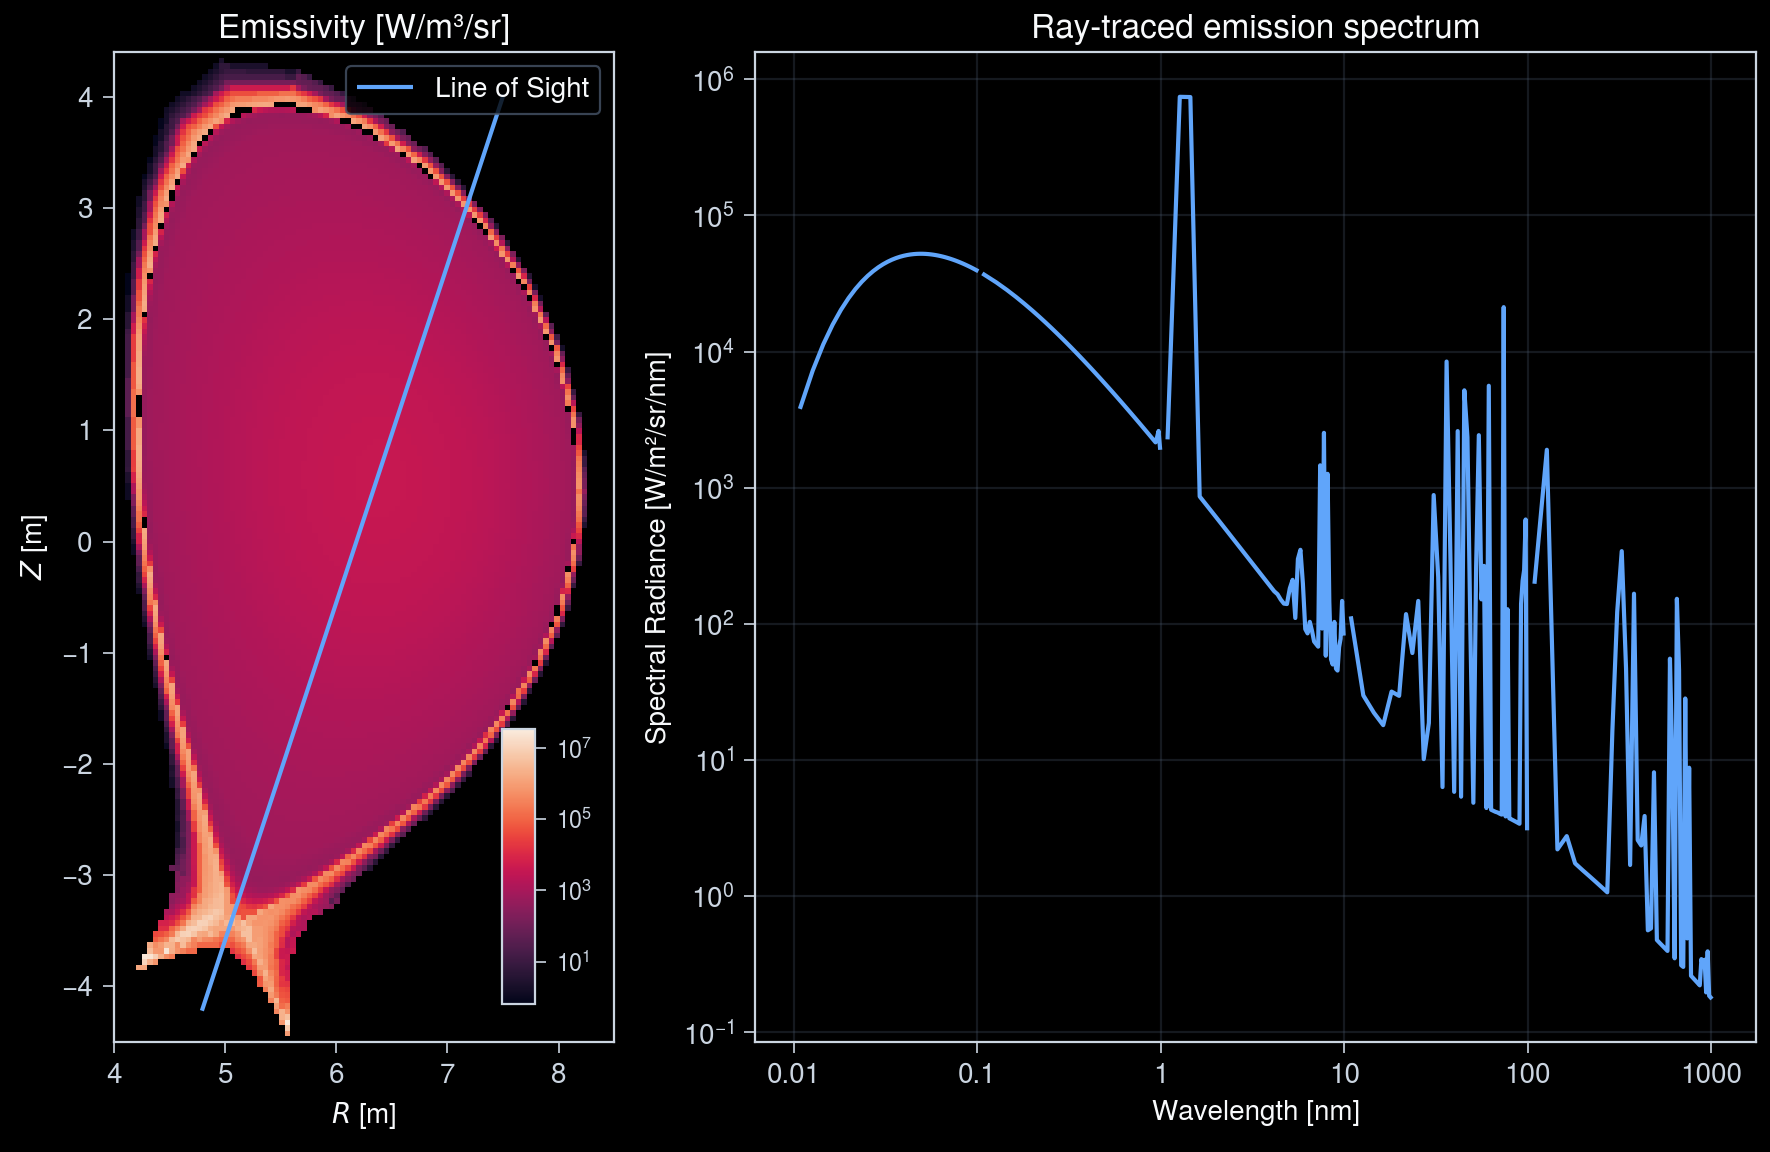

In [14]:
fig, axs = uplt.subplots([1, 2, 2], share=False)

# Plot 2-D emissivity map
image = axs[0].imshow(
    emission_2d.T,
    extent=extent,
    origin="lower",
    norm="log",
    cmap="rocket",
)
axs[0].colorbar(
    image,
    formatter="log",
    tickdir="out",
    loc="lr",
    orientation="vertical",
    ticklabelsize="small",
    length=5,
    frame=False,
)

# Plot line of sight
axs[0].plot(
    [origin.x, endpoint.x],
    [origin.z, endpoint.z],
    color="C0",
    label="Line of Sight",
    legend="ur",
)

axs[0].format(
    aspect="equal",
    xlabel="$R$ [m]",
    ylabel="$Z$ [m]",
    xreverse=False,
    ylocator=1,
    xlocator=1,
    title="Emissivity [W/m³/sr]",
    gridalpha=0.1,
)

# Plot 1-D measured spectrum
for s in spectra:
    axs[1].loglog(s.wavelengths, s.samples, color="C0")

axs[1].format(
    title="Ray-traced emission spectrum",
    xlabel="Wavelength [nm]",
    ylabel="Spectral Radiance [W/m²/sr/nm]",
    yformatter="log",
    grid=True,
    gridalpha=0.3,
)

In [15]:
print(
    "Total radiance along line of sight: ",
    f"{sum([s.total() for s in spectra]):.3g} W/m²/sr",
)

Total radiance along line of sight:  4.32e+05 W/m²/sr


Let us also plot the bar chart of the integrated spectrum for each wavelength band to see which wavelength bands dominate the total emission.

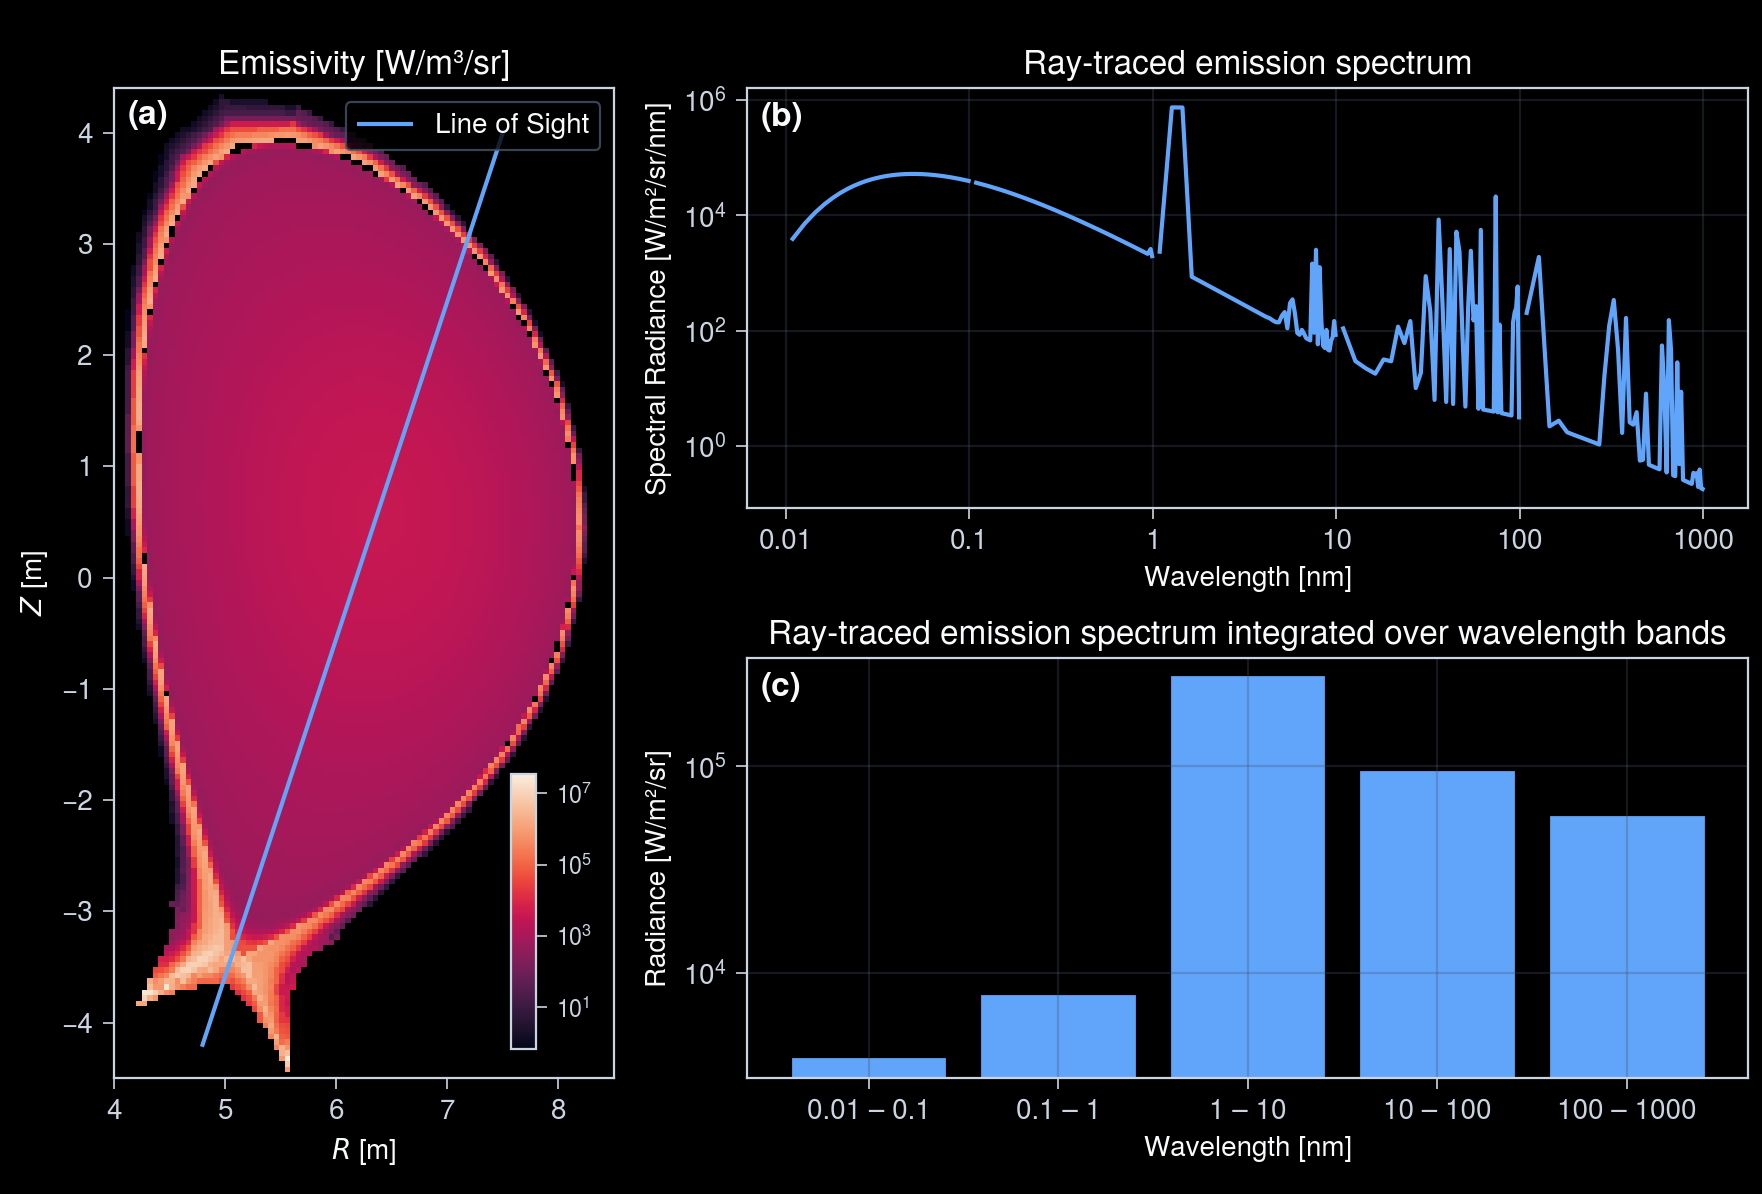

In [16]:
fig, axs = uplt.subplots([[1, 2, 2], [1, 3, 3]], share=False)

# Plot 2-D emissivity map
image = axs[0].imshow(
    emission_2d.T,
    extent=extent,
    origin="lower",
    norm="log",
    cmap="rocket",
)
axs[0].colorbar(
    image,
    formatter="log",
    tickdir="out",
    loc="lr",
    orientation="vertical",
    ticklabelsize="small",
    length=5,
    frame=False,
)

# Plot line of sight
axs[0].plot(
    [origin.x, endpoint.x],
    [origin.z, endpoint.z],
    color="C0",
    label="Line of Sight",
    legend="ur",
)

axs[0].format(
    aspect="equal",
    xlabel="$R$ [m]",
    ylabel="$Z$ [m]",
    xreverse=False,
    ylocator=1,
    xlocator=1,
    title="Emissivity [W/m³/sr]",
    gridalpha=0.1,
)

# Plot 1-D measured spectrum
for s in spectra:
    axs[1].loglog(s.wavelengths, s.samples, color="C0")


# Plot histogram of integrated spectrum
axs[2].bar(
    np.arange(len(spectra)),
    [s.total() for s in spectra]
)

axs[1:].format(
    yscale="log",
    yformatter="log",
    grid=True,
    gridalpha=0.3,
)

axs[1].format(
    title="Ray-traced emission spectrum",
    xlabel="Wavelength [nm]",
    ylabel="Spectral Radiance [W/m²/sr/nm]",
)

axs[2].format(
    xlabel="Wavelength [nm]",
    title="Ray-traced emission spectrum integrated over wavelength bands",
    ylabel="Radiance [W/m²/sr]",
    xlocator=range(len(wavelength_bands)),
    xticklabels=[f"{band[0]:g} – {band[1]:g}" for band in wavelength_bands],
)

axs.format(
    abc="(a)",
    abcloc="ul",
    abcborder=False,
)

In this example, 1–10 nm wavelength band dominates the total emission.
The radiance ratio between the soft X‑ray (0.01–10 nm) and UV/visible (10–1000 nm) bands is given by the following calculation:

In [17]:
radiance_soft_xray = sum([s.total() for s in spectra[0:3]])
radiance_uv_visible = sum([s.total() for s in spectra[3:]])
print(f"soft X-ray radiance: {radiance_soft_xray:.3e} W/m²/sr")
print(f"UV/visible radiance: {radiance_uv_visible:.3e} W/m²/sr")
print(f"radiance ratio (soft X-ray / UV-visible): {radiance_soft_xray / radiance_uv_visible:.2f}")

soft X-ray radiance: 2.818e+05 W/m²/sr
UV/visible radiance: 1.501e+05 W/m²/sr
radiance ratio (soft X-ray / UV-visible): 1.88
